# BridgeWatch AI — Exploratory Data Analysis

**Project:** BridgeWatch AI — predicting whether a bridge's condition will deteriorate by its next inspection
**Data:** FHWA National Bridge Inventory (NBI), 2020–2025 annual snapshots, 7 states (CA, FL, MD, MI, NY, TX, WA)
**Author:** Edmund Goldsberry — UMBC DATA 606 Capstone

This notebook does three things, in order:

1. **Validate the raw data** — confirm schema consistency across all 42 files (7 states × 6 years), check for duplicates/missing values, and confirm the join key needed to link a bridge's records across years.
2. **Explore the data** — distributions of the target and key candidate features, geographic coverage, and condition-rating patterns.
3. **Build the model-ready dataset** — construct the `deteriorated_next_period` label by pairing each bridge's consecutive annual records, assemble the feature table, and confirm it's ready to hand to a training notebook.


In [1]:
import glob
import os
import shutil

# Plotly's Kaleido image export needs a Chrome/Chromium binary. Use whatever is already
# on PATH; fall back to this sandbox's pre-installed copy if nothing else is found.
if not shutil.which("google-chrome") and not shutil.which("chromium") and not shutil.which("chromium-browser"):
    _fallback_chrome = "/opt/pw-browsers/chromium-1194/chrome-linux/chrome"
    if os.path.exists(_fallback_chrome):
        os.environ.setdefault("BROWSER_PATH", _fallback_chrome)

import numpy as np
import pandas as pd
import plotly.express as px
import plotly.io as pio

pio.renderers.default = "png"  # static images so the notebook renders anywhere (GitHub, nbviewer, etc.)
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)

DATA_DIR = os.path.join("..", "data")
STATES = ["CA", "FL", "MD", "MI", "NY", "TX", "WA"]
YEARS = ["20", "21", "22", "23", "24", "25"]
KEY = "STRUCTURE_NUMBER_008"

def path(state, year):
    return os.path.join(DATA_DIR, f"{state}{year}.txt")

def load(state, year, usecols=None):
    df = pd.read_csv(path(state, year), dtype=str, keep_default_na=False, usecols=usecols)
    df[KEY] = df[KEY].str.strip()
    df["STATE"] = state
    df["YEAR"] = 2000 + int(year)
    return df

all_files = sorted(glob.glob(os.path.join(DATA_DIR, "*.txt")))
print(f"{len(all_files)} state-year files found for {len(STATES)} states x {len(YEARS)} years")


42 state-year files found for 7 states x 6 years


## 1. Schema Validation

Every one of these 42 files needs the exact same column layout for the year-over-year join to work. FHWA changed its bridge coding standard (moving toward the new "Specification for the National Bridge Inventory") around this period, so this check is not a formality — it is the first thing that could have silently broken the whole approach.


In [2]:
headers = {}
for f in all_files:
    with open(f) as fh:
        headers[os.path.basename(f)] = fh.readline().strip()

unique_headers = set(headers.values())
print(f"Unique header signatures across all {len(headers)} files: {len(unique_headers)}")

ncols = len(next(iter(headers.values())).split(","))
print(f"Columns per file: {ncols}")

if len(unique_headers) == 1:
    print("PASS: All 42 files share an identical 123-column schema. Safe to join across years/states.")
else:
    print("WARNING: schema drift detected — inspect per-file headers before proceeding.")


Unique header signatures across all 42 files: 1
Columns per file: 123
PASS: All 42 files share an identical 123-column schema. Safe to join across years/states.


## 2. Load the Full Feature Set (2025 snapshot)

For feature-level exploration we only need one row per bridge, so we use the most recent (2025) snapshot across all 7 states. For the deterioration *label*, we'll go back and load all 6 years with a smaller column set (Section 5) — loading all 123 columns for all 6 years for all 7 states at once isn't necessary and wastes memory.


In [3]:
snap25 = pd.concat([load(s, "25") for s in STATES], ignore_index=True)
print("Combined 2025 snapshot shape:", snap25.shape)
snap25[[KEY, "STATE", "FACILITY_CARRIED_007", "YEAR_BUILT_027", "BRIDGE_CONDITION"]].head()


Combined 2025 snapshot shape: (139079, 125)


,STRUCTURE_NUMBER_008,STATE,FACILITY_CARRIED_007,YEAR_BUILT_027,BRIDGE_CONDITION
0,06 0021,CA,'Interstate 5 & RR',1941,F
1,1CA0070,CA,'LAGUNA ROAD',1949,P
2,1CA0095,CA,'VEHICLE ROAD',1985,F
3,1CA0141,CA,'MAIN ROAD',1948,F
4,1CA0142,CA,'LAS POSAS ROAD',1948,P


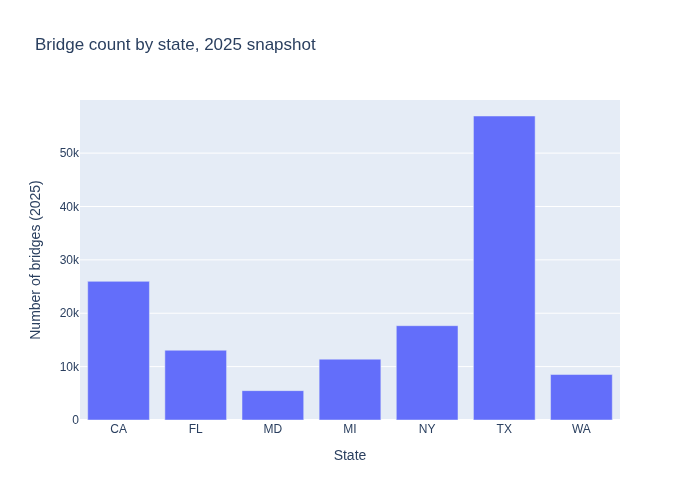

STATE
CA    25975
FL    13070
MD     5500
MI    11397
NY    17666
TX    56951
WA     8520
Name: count, dtype: int64


In [4]:
counts = snap25["STATE"].value_counts().reindex(STATES)
fig = px.bar(counts, x=counts.index, y=counts.values,
             labels={"x": "State", "y": "Number of bridges (2025)"},
             title="Bridge count by state, 2025 snapshot")
fig.show()
print(counts)


## 3. Data Quality Checks

### 3.1 Duplicate rows / duplicate keys


In [5]:
dup_report = []
for s in STATES:
    for y in YEARS:
        df = load(s, y, usecols=[KEY])
        n_dup_rows = df.duplicated().sum()
        n_dup_keys = df[KEY].duplicated().sum()
        if n_dup_rows or n_dup_keys:
            dup_report.append((s, y, n_dup_rows, n_dup_keys))

if dup_report:
    print("Files with duplicate rows or duplicate structure numbers:")
    for s, y, ndr, ndk in dup_report:
        print(f"  {s}{y}: duplicate_rows={ndr}, duplicate_keys={ndk}")
else:
    print("No duplicates found.")


Files with duplicate rows or duplicate structure numbers:
  CA21: duplicate_rows=1, duplicate_keys=1
  TX22: duplicate_rows=1, duplicate_keys=1


Two files carry a duplicate `STRUCTURE_NUMBER_008`:

- **CA21**, key `42 0160` — two genuinely *different* bridges (different `YEAR_BUILT`, different `LOCATION_009`) that were accidentally issued the same structure number in the source data — a real-world FHWA data entry error, not a parsing artifact.
- **TX22**, key `212140FD3018001` — an exact duplicate row (every field identical).

**Wrangling decision:** drop the TX22 exact duplicate with `drop_duplicates()`; for the CA21 collision, drop both rows for that key rather than guessing which record is authoritative — 2 rows out of ~682K is negligible.


In [6]:
def clean_state_year(df):
    df = df.drop_duplicates()
    dup_keys = df[KEY][df[KEY].duplicated(keep=False)]
    if len(dup_keys):
        df = df[~df[KEY].isin(dup_keys)]
    return df


### 3.2 Missing values

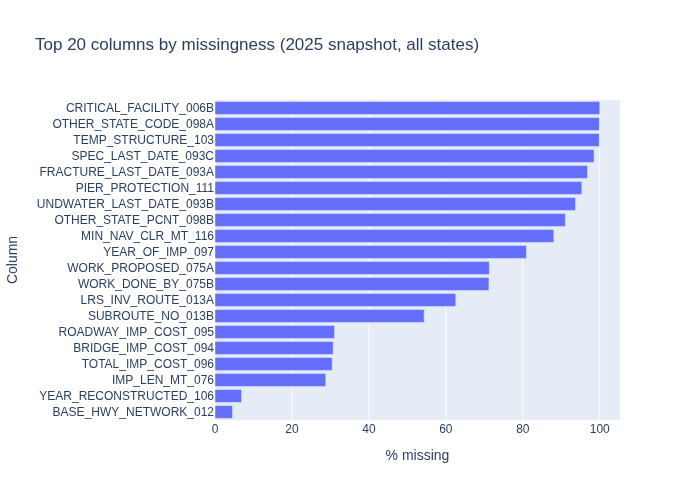

In [7]:
missing_pct = (snap25.replace("", np.nan).isna().mean() * 100).sort_values(ascending=False)
top_missing = missing_pct[missing_pct > 0].head(20)
fig = px.bar(top_missing, x=top_missing.values, y=top_missing.index, orientation="h",
             labels={"x": "% missing", "y": "Column"},
             title="Top 20 columns by missingness (2025 snapshot, all states)")
fig.update_layout(yaxis=dict(autorange="reversed"))
fig.show()


Most of this "missingness" is expected and structural, not a data quality problem:

- Fields like `FRACTURE_LAST_DATE_093A`, `UNDWATER_LAST_DATE_093B`, `SPEC_LAST_DATE_093C` are blank whenever that *type* of special inspection doesn't apply to a given bridge.
- `CULVERT_COND_062` is blank for the ~70% of bridges that aren't culverts (they use `DECK_COND_058`/`SUPERSTRUCTURE_COND_059`/`SUBSTRUCTURE_COND_060` instead) — and vice versa. These four fields are mutually exclusive by design, and `LOWEST_RATING`/`BRIDGE_CONDITION` are FHWA's own pre-computed rollup that already accounts for this, which is why we'll use those as the modeling target instead of the raw component ratings directly.

The columns worth real attention are ones with unexpected missingness in fields we plan to use as predictors — checked individually in Section 4.


### 3.3 Join-key stability across years

The whole "did it deteriorate by next inspection" approach depends on `STRUCTURE_NUMBER_008` reliably identifying the same physical bridge from one year's file to the next. We check retention rates for consecutive years.


In [8]:
retention_rows = []
for s in STATES:
    keys = {y: set(load(s, y, usecols=[KEY])[KEY]) for y in YEARS}
    for a, b in zip(YEARS, YEARS[1:]):
        common = keys[a] & keys[b]
        retention_rows.append({
            "state": s, "from": f"20{a}", "to": f"20{b}",
            "n_from": len(keys[a]), "n_common": len(common),
            "retention_pct": 100 * len(common) / len(keys[a]),
        })

retention = pd.DataFrame(retention_rows)
print(retention.groupby("state")["retention_pct"].agg(["min", "mean", "max"]).round(2))


         min   mean    max
state                     
CA     99.40  99.55  99.72
FL     99.21  99.41  99.55
MD     99.74  99.78  99.82
MI     99.80  99.83  99.85
NY     99.79  99.84  99.89
TX     99.22  99.29  99.35
WA     99.52  99.63  99.87


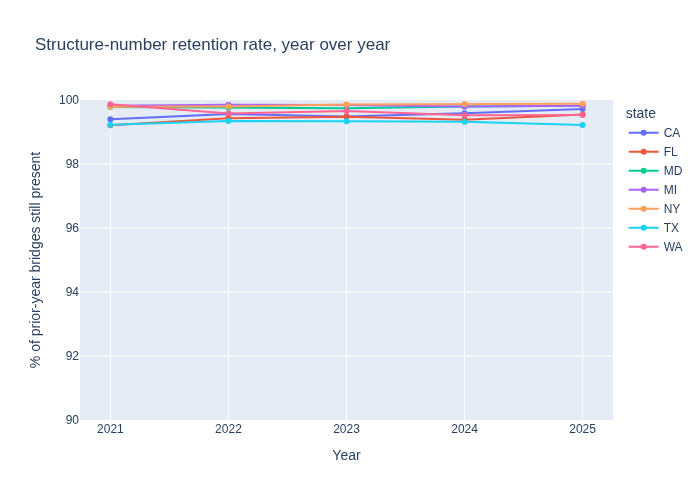

In [9]:
fig = px.line(retention, x="to", y="retention_pct", color="state", markers=True,
              labels={"to": "Year", "retention_pct": "% of prior-year bridges still present"},
              title="Structure-number retention rate, year over year")
fig.update_yaxes(range=[90, 100])
fig.show()


Retention is consistently in the high 90s% for every state — the ~1-4% drop each year is bridges being retired, replaced, or newly assigned a different structure number after major reconstruction, which is expected turnover in a live infrastructure inventory, not a data problem. `STRUCTURE_NUMBER_008` is a reliable join key.


## 4. Feature Exploration

### 4.1 Bridge age


count    139079.000000
mean         48.131717
std          26.374050
min           0.000000
25%          26.000000
50%          50.000000
75%          65.000000
max         225.000000
Name: YEAR_BUILT_027, dtype: float64
Implausible ages (<0 or >200): 5


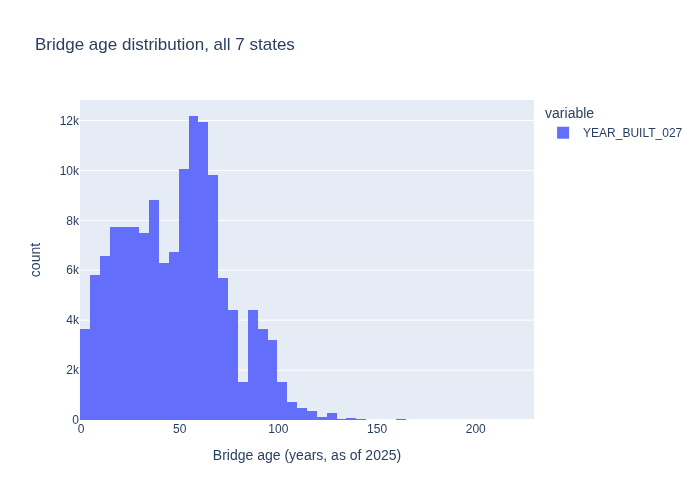

In [10]:
age = 2025 - pd.to_numeric(snap25["YEAR_BUILT_027"], errors="coerce")
print(age.describe())
print("Implausible ages (<0 or >200):", ((age < 0) | (age > 200)).sum())

fig = px.histogram(age, nbins=60, labels={"value": "Bridge age (years, as of 2025)"},
                    title="Bridge age distribution, all 7 states")
fig.show()


### 4.2 Traffic volume (Average Daily Traffic)

count    139079.000000
mean      14637.801235
std       32511.670087
min           0.000000
25%         469.000000
50%        3400.000000
75%       13631.000000
max      810110.000000
Name: ADT_029, dtype: float64
Zero-ADT bridges: 684 (0.49%)


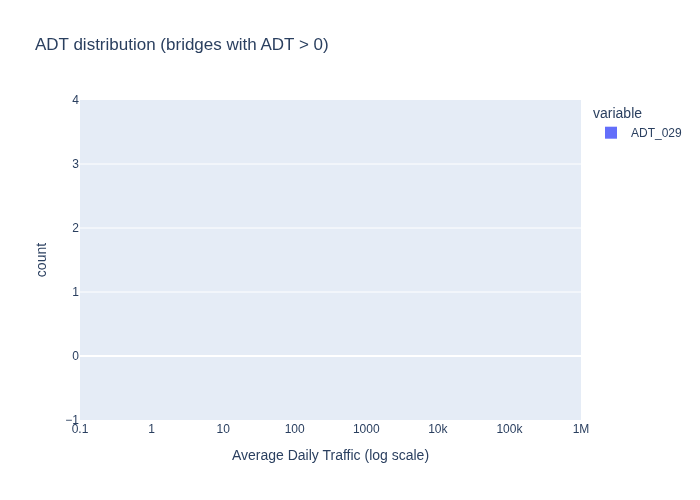

In [11]:
adt = pd.to_numeric(snap25["ADT_029"], errors="coerce")
print(adt.describe())
print("Zero-ADT bridges:", (adt == 0).sum(), f"({100*(adt==0).mean():.2f}%)")

fig = px.histogram(adt[adt > 0], nbins=60, log_x=True,
                    labels={"value": "Average Daily Traffic (log scale)"},
                    title="ADT distribution (bridges with ADT > 0)")
fig.show()


### 4.3 Geolocation — decoding NBI's packed lat/long format

`LAT_016` and `LONG_017` are stored as fixed-width, unsigned integers packing degrees-minutes-seconds
(`DDMMSSss` for latitude, `DDDMMSSss` for longitude — one extra digit because longitude can reach 180°).
There's no decimal point and no sign, so these need decoding before they're usable for the Streamlit risk map,
and every continental-US longitude needs to be negated (West).


In [12]:
blank_lat = (snap25["LAT_016"].str.strip() == "").sum()
blank_lon = (snap25["LONG_017"].str.strip() == "").sum()
print(f"Blank LAT_016: {blank_lat}, blank LONG_017: {blank_lon} (out of {len(snap25)} bridges)")
print(snap25.loc[snap25["LAT_016"].str.strip() == "", ["STATE", KEY]].groupby("STATE").size())


Blank LAT_016: 10, blank LONG_017: 9 (out of 139079 bridges)
STATE
MD    6
WA    4
dtype: int64


A handful of bridges (10 out of ~139K, all in MD and WA) have a blank coordinate field —
negligible for modeling, but the decode function needs to tolerate it rather than crash, since a
production pipeline (or the Streamlit app) will see the same gaps in other states/years.


In [13]:
import re
_DIGITS_ONLY = re.compile(r"^\d+$")

nonstd = snap25.loc[snap25["LONG_017"].str.strip().map(lambda v: v != "" and not _DIGITS_ONLY.match(v))]
print(f"Non-digit-only LONG_017 values (2025 snapshot): {len(nonstd)} / {len(snap25)} "
      f"({100*len(nonstd)/len(snap25):.2f}%)")
print(nonstd[["STATE", "LONG_017"]].head(10).to_string())


Non-digit-only LONG_017 values (2025 snapshot): 370 / 139079 (0.27%)
      STATE   LONG_017
39226    MD  -00000007
39228    MD  -00000007
39231    MD  -00000007
39233    MD  -00000007
39236    MD  -00000007
39244    MD  -00000007
39249    MD  -00000007
39256    MD  -00000007
39270    MD  -00000007
39273    MD  -00000007


A small fraction of records — checked across the full 42-file dataset, **0.24% of rows** (2,010 out of
824,312), concentrated in the 2020–2021 files — store `LONG_017` as an already-signed decimal-looking value
(e.g. `'-1220152.'`, `'-07672454'`) instead of the standard unsigned `DDDMMSSss` packed integer every other
record uses. The digit count and implied precision aren't even consistent across the offending records
(some look like degrees×10⁴, others ×10⁶), so there is no single safe formula to reverse-engineer —
inventing one risks quietly injecting wrong coordinates into a small slice of the map/model.

**Wrangling decision:** detect any `LAT_016`/`LONG_017` value that isn't a plain digit string and decode
it to `NaN` rather than guess. At 0.24% of rows this is immaterial to model training and only affects
whether that specific bridge can be plotted on the map — accuracy there matters more than coverage.


In [14]:
def decode_lat(x):
    x = x.strip()
    if not _DIGITS_ONLY.match(x):
        return np.nan
    x = int(x)
    dd, mm, ss = x // 1_000_000, (x // 10_000) % 100, (x % 10_000) / 100
    return dd + mm / 60 + ss / 3600

def decode_long(x):
    x = x.strip()
    if not _DIGITS_ONLY.match(x):
        return np.nan
    x = int(x)
    ddd, mm, ss = x // 1_000_000, (x // 10_000) % 100, (x % 10_000) / 100
    return -(ddd + mm / 60 + ss / 3600)

snap25["lat"] = snap25["LAT_016"].apply(decode_lat)
snap25["lon"] = snap25["LONG_017"].apply(decode_long)

# Each state's rough bounding box, used both to *validate* decoded coordinates and,
# below, to null out the ones that fail the check.
BOUNDS = {
    "CA": (32.0, 42.5, -125.0, -113.5), "FL": (24.4, 31.1, -87.7, -79.8),
    "MD": (37.8, 39.8, -79.6, -74.9),   "MI": (41.6, 48.3, -90.5, -82.1),
    "NY": (40.4, 45.1, -79.9, -71.7),   "TX": (25.7, 36.6, -106.7, -93.4),
    "WA": (45.5, 49.1, -124.9, -116.9),
}

def in_bounds(df):
    """Boolean mask: True where (lat, lon, STATE) falls inside that state's bounding box.
    NaN coordinates evaluate to False here, which is fine — they're already excluded elsewhere."""
    lo_lat = df["STATE"].map(lambda s: BOUNDS[s][0])
    hi_lat = df["STATE"].map(lambda s: BOUNDS[s][1])
    lo_lon = df["STATE"].map(lambda s: BOUNDS[s][2])
    hi_lon = df["STATE"].map(lambda s: BOUNDS[s][3])
    return df["lat"].between(lo_lat, hi_lat) & df["lon"].between(lo_lon, hi_lon)

valid_format = snap25["lat"].notna() & snap25["lon"].notna()
out_of_bounds = valid_format & ~in_bounds(snap25)
print(f"Well-formatted but geographically implausible coordinates: {out_of_bounds.sum()} / {len(snap25)}")
print(snap25.loc[out_of_bounds, "STATE"].value_counts())
print()
print("Examples:")
print(snap25.loc[out_of_bounds, [KEY, "STATE", "LAT_016", "LONG_017", "lat", "lon"]].head(8).to_string())


Well-formatted but geographically implausible coordinates: 146 / 139079
STATE
MD    138
FL      4
NY      2
MI      1
WA      1
Name: count, dtype: int64

Examples:
      STRUCTURE_NUMBER_008 STATE   LAT_016   LONG_017        lat         lon
31297               484307    FL  30313390  097135040  30.526083  -97.230667
35726               795703    FL  02900470  080545470   3.501306  -80.915194
37145               871200    FL  25575853  008085101  25.966258   -8.147503
37146               871201    FL  25575813  008085091  25.966147   -8.147475
39099      100000010047010    MD  39529494  785434000  39.893039 -785.727778
39101      100000010049010    MD  39539243  078455459  39.909008  -78.765164
39116      100000010064010    MD  00000000  000000000   0.000000   -0.000000
39232      100000020008010    MD  00000039  000000076   0.000108   -0.000211


These pass the "is it a digit string" check but decode to nonsense — mostly recognizable **sentinel/placeholder
patterns** rather than real GPS drift: all-zeros (`00000000`/`000000000`), all-nines (`99999999`), and a
suspicious repeating short code (`00000039` paired with `000000076`/`000000077`) that shows up across dozens
of unrelated Maryland bridges — almost certainly a "coordinate not yet surveyed" placeholder from the source
system, not a real location. A few others (e.g. `LONG_017` with a `7` where a `0` belongs) look like manual
transposition errors. Either way, trusting the packed-integer decode alone isn't sufficient — a plausibility
check against the state's bounding box is required.

**Wrangling decision:** treat any decoded coordinate that falls outside its state's bounding box the same as
a missing one (`NaN`) — for the map and for any spatial features, not just for California. This is applied
consistently in the model-ready dataset built in Section 6, not just here.


In [15]:
snap25.loc[out_of_bounds, ["lat", "lon"]] = np.nan
print(f"After masking: {snap25['lat'].isna().sum()} bridges with no usable coordinate "
      f"({100*snap25['lat'].isna().mean():.2f}% of {len(snap25)})")


After masking: 156 bridges with no usable coordinate (0.11% of 139079)


A basemap (`scatter_geo`/`scatter_mapbox`) needs to fetch boundary tiles from an external CDN, which
this sandbox's network policy blocks — not a data issue, just an environment restriction. A plain lon/lat
scatter (no basemap) still confirms the geographic spread is sane and clusters correctly by state; the
Streamlit app (running outside this sandbox) can layer the same decoded coordinates onto a real basemap.


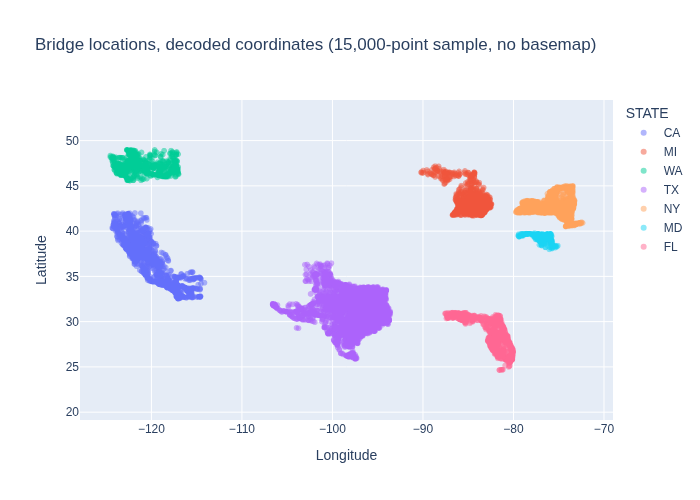

In [16]:
sample = snap25.dropna(subset=["lat", "lon"]).sample(15000, random_state=42)
fig = px.scatter(sample, x="lon", y="lat", color="STATE", opacity=0.5,
                  labels={"lon": "Longitude", "lat": "Latitude"},
                  title="Bridge locations, decoded coordinates (15,000-point sample, no basemap)")
fig.update_yaxes(scaleanchor="x", scaleratio=1)
fig.show()


### 4.4 Bridge condition — the rollup target field

BRIDGE_CONDITION
F    68112
G    64939
P     6028
Name: count, dtype: int64 

BRIDGE_CONDITION
F    49.0
G    46.7
P     4.3
Name: count, dtype: float64


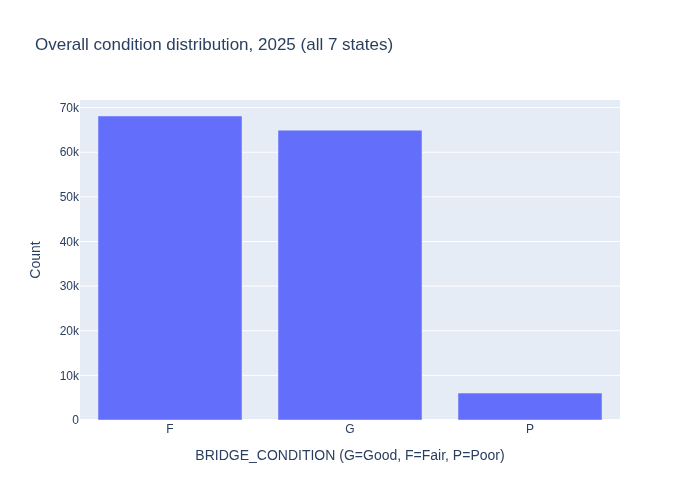

In [17]:
cond = snap25["BRIDGE_CONDITION"].value_counts()
print(cond, "\n")
print((100 * cond / len(snap25)).round(1))

fig = px.bar(cond, x=cond.index, y=cond.values,
             labels={"x": "BRIDGE_CONDITION (G=Good, F=Fair, P=Poor)", "y": "Count"},
             title="Overall condition distribution, 2025 (all 7 states)")
fig.show()


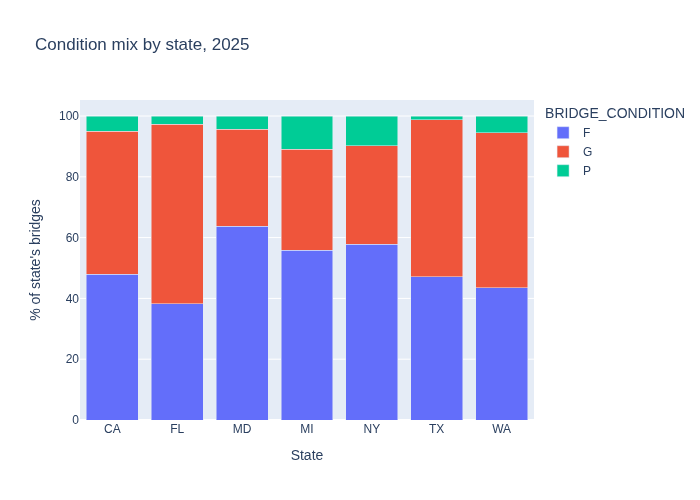

BRIDGE_CONDITION     F     G     P
STATE                             
CA                47.9  47.1   4.9
FL                38.3  59.0   2.8
MD                63.8  31.9   4.4
MI                55.9  33.1  11.0
NY                57.9  32.3   9.9
TX                47.1  51.7   1.2
WA                43.5  51.0   5.6


In [18]:
cond_by_state = pd.crosstab(snap25["STATE"], snap25["BRIDGE_CONDITION"], normalize="index") * 100
fig = px.bar(cond_by_state, barmode="stack",
             labels={"value": "% of state's bridges", "STATE": "State"},
             title="Condition mix by state, 2025")
fig.show()
print(cond_by_state.round(1))


### 4.5 Condition vs. age and material

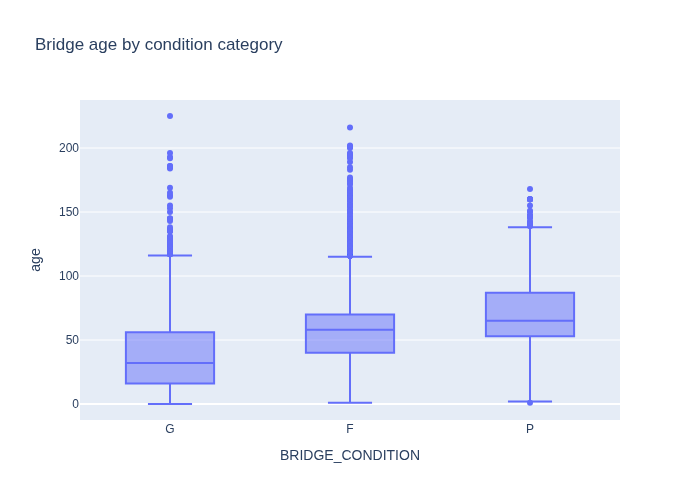

In [19]:
snap25["age"] = 2025 - pd.to_numeric(snap25["YEAR_BUILT_027"], errors="coerce")
fig = px.box(snap25.dropna(subset=["age"]), x="BRIDGE_CONDITION", y="age",
             category_orders={"BRIDGE_CONDITION": ["G", "F", "P"]},
             title="Bridge age by condition category")
fig.show()


`STRUCTURE_KIND_043A` (FHWA Recording & Coding Guide, Item 43A) encodes the primary material/design:
1/2 = concrete (simple/continuous span), 3/4 = steel, 5/6 = prestressed concrete, 7 = wood/timber,
8 = masonry, 9 = aluminum/wrought/cast iron, 0 = other.


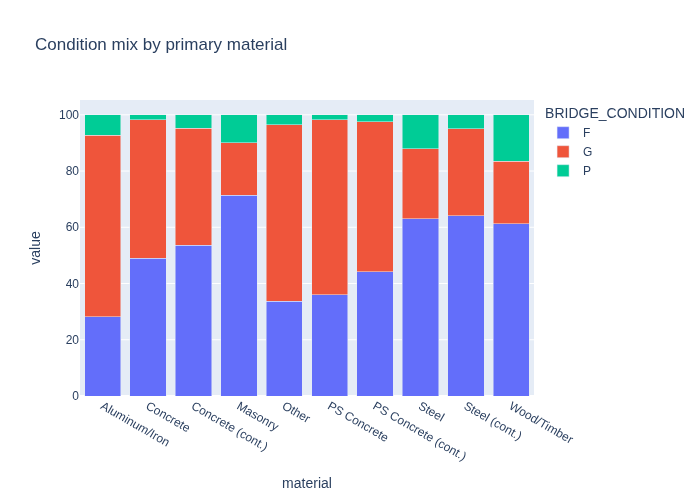

BRIDGE_CONDITION        F     G     P
material                             
Aluminum/Iron        28.2  64.5   7.3
Concrete             49.0  49.2   1.8
Concrete (cont.)     53.6  41.6   4.8
Masonry              71.3  18.8   9.9
Other                33.6  62.8   3.5
PS Concrete          36.0  62.2   1.7
PS Concrete (cont.)  44.3  53.2   2.5
Steel                63.0  25.0  12.0
Steel (cont.)        64.2  30.9   4.9
Wood/Timber          61.2  22.4  16.5


In [20]:
material_map = {"1": "Concrete", "2": "Concrete (cont.)", "3": "Steel", "4": "Steel (cont.)",
                "5": "PS Concrete", "6": "PS Concrete (cont.)", "7": "Wood/Timber",
                "8": "Masonry", "9": "Aluminum/Iron", "0": "Other"}
snap25["material"] = snap25["STRUCTURE_KIND_043A"].map(material_map).fillna("Unknown")

cond_by_material = pd.crosstab(snap25["material"], snap25["BRIDGE_CONDITION"], normalize="index") * 100
fig = px.bar(cond_by_material, barmode="stack",
             title="Condition mix by primary material")
fig.show()
print(cond_by_material.round(1))


## 5. Building the `deteriorated_next_period` Target

For each state, we pair every consecutive year (2020→21, 21→22, ..., 24→25). A bridge's row from year *A* supplies
the **features**; its `LOWEST_RATING` in year *B* supplies the **label**:

```
deteriorated_next_period = 1  if LOWEST_RATING(year B) < LOWEST_RATING(year A)
                          = 0  otherwise (stable or improved)
```

`LOWEST_RATING` (the minimum of deck/superstructure/substructure/culvert condition, whichever apply) is fully populated
for every bridge (0% missing, checked below) and numeric on a consistent 0–9 scale, unlike `BRIDGE_CONDITION`'s coarse
3-bucket rollup — so it gives a cleaner, more sensitive deterioration signal.


In [21]:
lr_missing = pd.to_numeric(snap25["LOWEST_RATING"], errors="coerce").isna().mean() * 100
print(f"LOWEST_RATING missing: {lr_missing:.2f}%")


LOWEST_RATING missing: 0.00%


In [22]:
FEATURE_COLS = [
    KEY, "COUNTY_CODE_003", "YEAR_BUILT_027", "ADT_029", "YEAR_ADT_030",
    "PERCENT_ADT_TRUCK_109", "STRUCTURE_KIND_043A", "STRUCTURE_TYPE_043B",
    "MAIN_UNIT_SPANS_045", "APPR_SPANS_046", "STRUCTURE_LEN_MT_049", "MAX_SPAN_LEN_MT_048",
    "DECK_WIDTH_MT_052", "TRAFFIC_LANES_ON_028A", "DECK_STRUCTURE_TYPE_107",
    "SCOUR_CRITICAL_113", "OWNER_022", "FUNCTIONAL_CLASS_026",
    "DATE_OF_INSPECT_090", "INSPECT_FREQ_MONTHS_091",
    "LAT_016", "LONG_017",
    "DECK_COND_058", "SUPERSTRUCTURE_COND_059", "SUBSTRUCTURE_COND_060", "CULVERT_COND_062",
    "LOWEST_RATING", "BRIDGE_CONDITION",
]

def build_transitions(state):
    frames = {y: clean_state_year(load(state, y, usecols=FEATURE_COLS)) for y in YEARS}
    out = []
    for a, b in zip(YEARS, YEARS[1:]):
        label = frames[b][[KEY, "LOWEST_RATING", "BRIDGE_CONDITION"]].rename(
            columns={"LOWEST_RATING": "LOWEST_RATING_next", "BRIDGE_CONDITION": "BRIDGE_CONDITION_next"})
        merged = frames[a].merge(label, on=KEY, how="inner")
        merged["from_year"] = 2000 + int(a)
        merged["to_year"] = 2000 + int(b)
        out.append(merged)
    return pd.concat(out, ignore_index=True)

transitions = pd.concat([build_transitions(s) for s in STATES], ignore_index=True)
print("Combined bridge-year-transition dataset shape:", transitions.shape)


Combined bridge-year-transition dataset shape: (681841, 34)


In [23]:
transitions["LOWEST_RATING"] = pd.to_numeric(transitions["LOWEST_RATING"], errors="coerce")
transitions["LOWEST_RATING_next"] = pd.to_numeric(transitions["LOWEST_RATING_next"], errors="coerce")
transitions = transitions.dropna(subset=["LOWEST_RATING", "LOWEST_RATING_next"])

transitions["deteriorated_next_period"] = (
    transitions["LOWEST_RATING_next"] < transitions["LOWEST_RATING"]
).astype(int)

label_counts = transitions["deteriorated_next_period"].value_counts()
print(label_counts)
print(f"\nDeterioration rate: {100 * transitions['deteriorated_next_period'].mean():.2f}%")
print(f"Class imbalance ratio (stable/improved : deteriorated) = "
      f"{label_counts[0] / label_counts[1]:.1f} : 1")


deteriorated_next_period
0    652258
1     29583
Name: count, dtype: int64

Deterioration rate: 4.34%
Class imbalance ratio (stable/improved : deteriorated) = 22.0 : 1


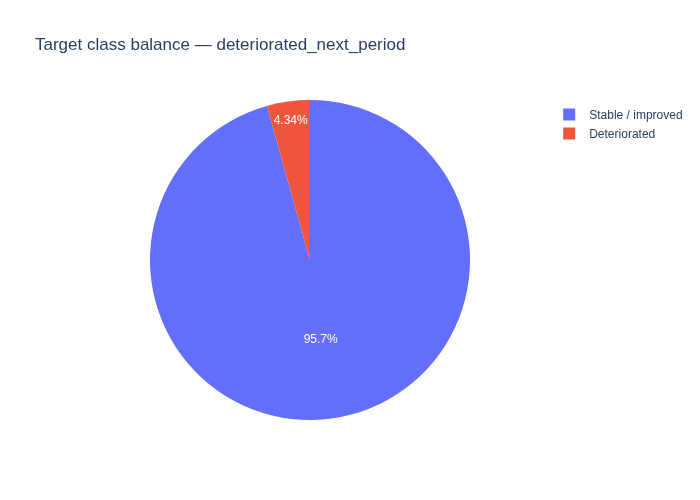

In [24]:
fig = px.pie(values=label_counts.values, names=["Stable / improved", "Deteriorated"],
             title="Target class balance — deteriorated_next_period")
fig.show()


       n_transitions  deterioration_rate_pct
STATE                                       
MI             56483                    7.07
NY             87739                    6.71
FL             63552                    4.35
CA            128396                    4.24
TX            276618                    3.44
WA             41824                    2.94
MD             27229                    2.75


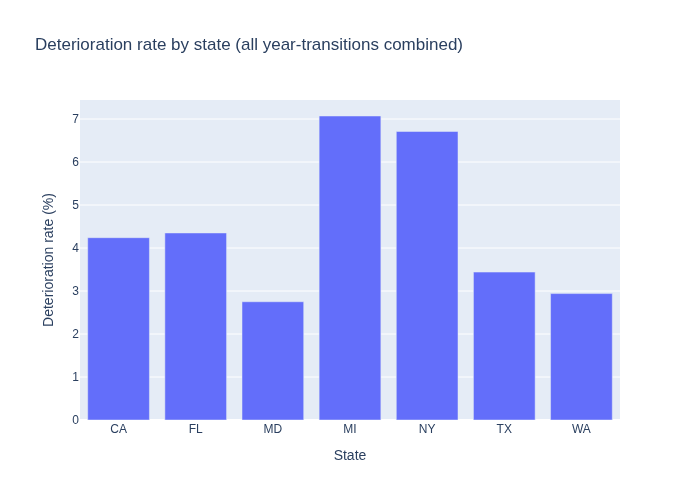

In [25]:
by_state = transitions.groupby("STATE")["deteriorated_next_period"].agg(["size", "mean"])
by_state["mean"] = (by_state["mean"] * 100).round(2)
by_state.columns = ["n_transitions", "deterioration_rate_pct"]
print(by_state.sort_values("deterioration_rate_pct", ascending=False))

fig = px.bar(by_state, x=by_state.index, y="deterioration_rate_pct",
             labels={"deterioration_rate_pct": "Deterioration rate (%)", "STATE": "State"},
             title="Deterioration rate by state (all year-transitions combined)")
fig.show()


         n_transitions  deterioration_rate_pct
to_year                                       
2021            134869                    4.67
2022            135587                    4.46
2023            136309                    3.94
2024            137156                    4.08
2025            137920                    4.54


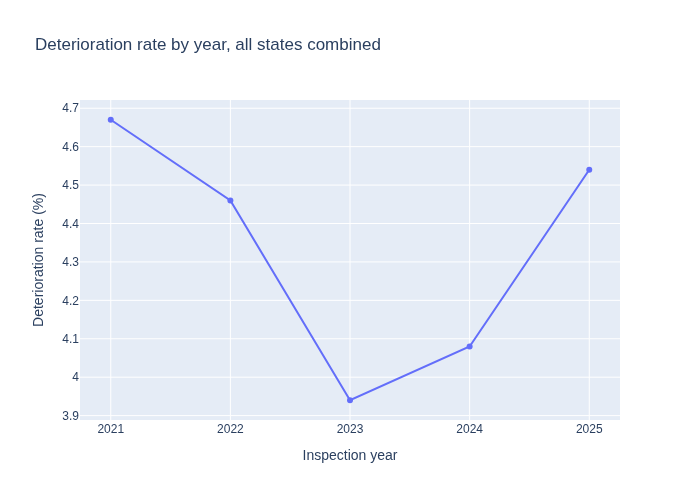

In [26]:
by_year = transitions.groupby("to_year")["deteriorated_next_period"].agg(["size", "mean"])
by_year["mean"] = (by_year["mean"] * 100).round(2)
by_year.columns = ["n_transitions", "deterioration_rate_pct"]
print(by_year)

fig = px.line(by_year, x=by_year.index, y="deterioration_rate_pct", markers=True,
              labels={"deterioration_rate_pct": "Deterioration rate (%)", "to_year": "Inspection year"},
              title="Deterioration rate by year, all states combined")
fig.show()


**Class imbalance is real and needs to be planned for at modeling time**, not treated as a data-quality problem:
across ~682K bridge-year transitions, only ~4.3% are labeled `deteriorated_next_period = 1` (~21:1 imbalance). This is
consistent with how the physical process works — condition ratings are sticky and typically drop by only one point
after years of gradual wear, so most bridges show no year-over-year change. The absolute count of positive examples
(~29,000) is large enough to train on; the modeling notebook will need class weighting (or resampling) and
should report precision/recall/F1/PR-AUC rather than raw accuracy, since a trivial "always predict stable" classifier
would already score ~96% accuracy.


## 6. Assembling the Model-Ready Table

A few derived fields make the raw NBI columns more directly usable as model features:
- `age` = inspection year − `YEAR_BUILT_027`
- `lat` / `lon` = decoded from `LAT_016` / `LONG_017` (Section 4.3), used for the map app and as spatial features
- categorical codes (`STRUCTURE_KIND_043A`, `OWNER_022`, `SCOUR_CRITICAL_113`, ...) are left as their raw FHWA codes here; one-hot/target encoding is a modeling-notebook decision, not an EDA one


In [27]:
model_df = transitions.copy()
model_df["age"] = model_df["from_year"] - pd.to_numeric(model_df["YEAR_BUILT_027"], errors="coerce")
model_df["lat"] = model_df["LAT_016"].apply(decode_lat)
model_df["lon"] = model_df["LONG_017"].apply(decode_long)

# Same two-layer coordinate validation as Section 4.3: digit-format check (done above via
# decode_lat/decode_long) plus a bounding-box plausibility check, so sentinel/placeholder
# coordinates don't leak into the model-ready table.
bad_coords = model_df["lat"].notna() & model_df["lon"].notna() & ~in_bounds(model_df)
model_df.loc[bad_coords, ["lat", "lon"]] = np.nan
print(f"Coordinates masked as implausible: {bad_coords.sum()} / {len(model_df)}")

model_df["ADT_029"] = pd.to_numeric(model_df["ADT_029"], errors="coerce")
model_df["months_since_inspection"] = pd.to_numeric(model_df["INSPECT_FREQ_MONTHS_091"], errors="coerce")

print("Final model-ready dataset:")
print(" shape:", model_df.shape)
print(" target balance:", model_df["deteriorated_next_period"].value_counts(normalize=True).round(4).to_dict())
print("\nMissingness in key modeling columns:")
key_feats = ["age", "ADT_029", "STRUCTURE_KIND_043A", "SCOUR_CRITICAL_113", "lat", "lon",
             "LOWEST_RATING", "months_since_inspection"]
print((model_df[key_feats].replace("", np.nan).isna().mean() * 100).round(2))


Coordinates masked as implausible: 987 / 681841


Final model-ready dataset:
 shape: (681841, 39)
 target balance: {0: 0.9566, 1: 0.0434}

Missingness in key modeling columns:
age                        0.00
ADT_029                    0.00
STRUCTURE_KIND_043A        0.00
SCOUR_CRITICAL_113         0.00
lat                        0.15
lon                        0.39
LOWEST_RATING              0.00
months_since_inspection    0.00
dtype: float64


In [28]:
# Saved gzip-compressed (~118MB uncompressed exceeds GitHub's 100MB per-file push limit).
# pandas reads it back transparently: pd.read_csv("bridge_deterioration_dataset.csv.gz")
out_dir = os.path.join(DATA_DIR, "processed")
os.makedirs(out_dir, exist_ok=True)
out_path = os.path.join(out_dir, "bridge_deterioration_dataset.csv.gz")
model_df.to_csv(out_path, index=False, compression="gzip")
print(f"Saved {model_df.shape[0]:,} rows x {model_df.shape[1]} columns to {out_path}")
print(f"File size: {os.path.getsize(out_path) / 1e6:.1f} MB")


Saved 681,841 rows x 39 columns to ../data/processed/bridge_deterioration_dataset.csv.gz
File size: 27.1 MB


## 7. Readiness Summary

**Confirmed ready for modeling:**
- Identical 123-column schema across all 42 raw files — no schema-drift handling needed.
- `STRUCTURE_NUMBER_008` is a reliable join key (96–100% year-over-year retention per state).
- `LOWEST_RATING` is 0% missing and numeric — a clean basis for the deterioration label.
- Decoded lat/long, after two-layer validation (digit-format check + bounding-box plausibility check), are usable for the Streamlit risk map for the ~99.5% of bridges that pass both checks.
- ~682K bridge-year-transition rows assembled with features + label, saved to `data/processed/bridge_deterioration_dataset.csv.gz`.

**Handled during wrangling:**
- Dropped 1 exact duplicate row (TX22) and 1 colliding-structure-number pair (CA21) — 2 rows total, immaterial to dataset size.
- Confirmed `CULVERT_COND_062` vs. `DECK/SUPERSTRUCTURE/SUBSTRUCTURE_COND` missingness is structural (mutually exclusive by design), not a defect — this is why `LOWEST_RATING`/`BRIDGE_CONDITION` were chosen as the target basis instead of a raw component column.
- Found and masked two distinct `LAT_016`/`LONG_017` data-quality issues rather than trusting the raw fields blindly: ~0.27% of records use a non-standard, ambiguous-precision signed-decimal format instead of the documented packed integer format, and a further ~0.4% decode successfully but land outside their state's borders — mostly recognizable sentinel/placeholder codes (`00000000`, `99999999`, a repeating `00000039`-style stub) rather than real GPS drift. Both are nulled out rather than guessed at, since incorrect coordinates would be worse than missing ones for a risk map.

**Open items for the modeling notebook, not this one:**
- Severe class imbalance (~4.3% positive) — needs class weighting/resampling and non-accuracy metrics (F1, recall, PR-AUC).
- Categorical encoding strategy for `STRUCTURE_KIND_043A`, `OWNER_022`, `SCOUR_CRITICAL_113`, etc.
- Whether to engineer a richer label than a single-year-lag binary flag (e.g., using `BRIDGE_CONDITION` category downgrades as a secondary/sanity-check label).
